# Análisis Exploratorio de Datos (EDA) - WeLoveReviews

## Objetivos del Negocio
Evaluar la discrepancia entre el sentimiento expresado en el texto de las reseñas de clientes y su calificación cuantitativa promedio (actualmente ~4.5/5 estrellas).
Este análisis nos permitirá entender si las altas calificaciones reflejan verdaderamente la satisfacción del cliente o si existen problemas subyacentes mencionados en los textos (falsos negativos en satisfacción o discrepancia texto-rating).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### 1. Carga del Dataset y Estructura Básica
Procedemos a cargar los datos y revisar su forma, tipos de datos y posibles valores nulos.

In [2]:
df = pd.read_csv('../data/raw/reviews.csv')
print(f"Forma del dataset: {df.shape}")
print("\nTipos de datos:")
print(df.dtypes)
print("\nValores nulos:")
print(df.isnull().sum())
print("\nDuplicados:", df.duplicated().sum())

Forma del dataset: (500, 3)

Tipos de datos:
review_id      int64
rating         int64
review_text      str
dtype: object

Valores nulos:
review_id      0
rating         0
review_text    0
dtype: int64

Duplicados: 0


### 2. Distribución de Calificaciones (Ratings)
Analizamos cómo se distribuyen las estrellas dadas por los usuarios.

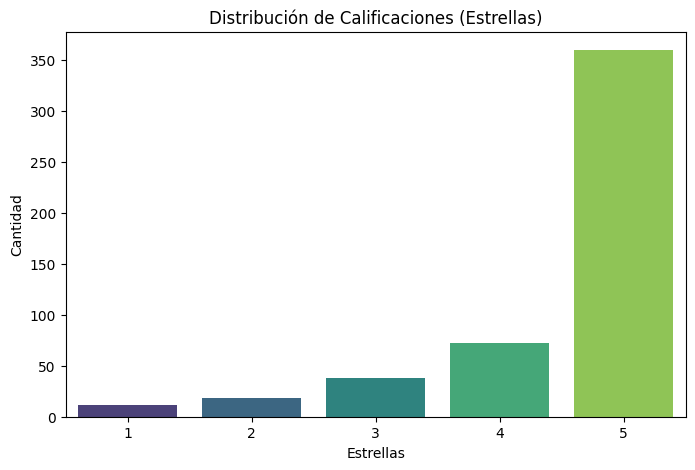

In [3]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='rating', palette='viridis')
plt.title('Distribución de Calificaciones (Estrellas)')
plt.xlabel('Estrellas')
plt.ylabel('Cantidad')
plt.show()

### 3. Estadísticas de Longitud de Texto
Exploraremos qué tan largas son las reseñas en promedio, lo que nos dará una idea de la riqueza de información que tienen.

Estadísticas de longitud de texto (caracteres):
count    500.000000
mean     170.170000
std       27.058778
min       86.000000
25%      155.000000
50%      173.000000
75%      189.000000
max      230.000000
Name: text_length, dtype: float64

Estadísticas de conteo de palabras:
count    500.000000
mean      29.104000
std        4.824078
min       14.000000
25%       26.000000
50%       29.000000
75%       32.000000
max       42.000000
Name: word_count, dtype: float64


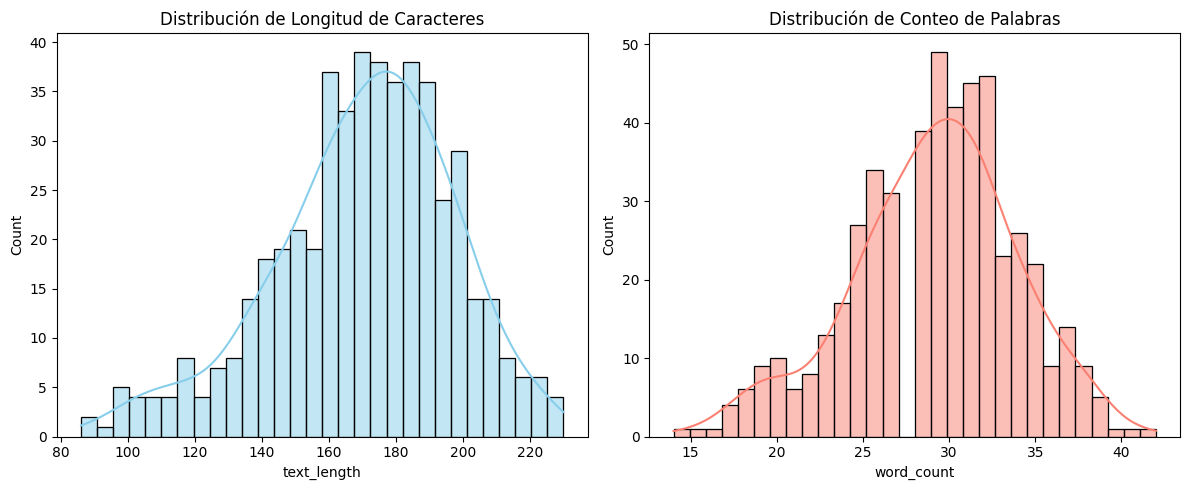

In [4]:
df['text_length'] = df['review_text'].astype(str).apply(len)
df['word_count'] = df['review_text'].astype(str).apply(lambda x: len(x.split()))

print("Estadísticas de longitud de texto (caracteres):")
print(df['text_length'].describe())
print("\nEstadísticas de conteo de palabras:")
print(df['word_count'].describe())

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['text_length'], bins=30, kde=True, color='skyblue')
plt.title('Distribución de Longitud de Caracteres')
plt.subplot(1, 2, 2)
sns.histplot(df['word_count'], bins=30, kde=True, color='salmon')
plt.title('Distribución de Conteo de Palabras')
plt.tight_layout()
plt.show()

### 4. Muestra de Textos
Observamos algunas reseñas al azar para entender su contenido y detectar el idioma.

In [5]:
pd.set_option('display.max_colwidth', None)
print(df[['rating', 'review_text']].sample(5, random_state=42))

     rating  \
361       3   
73        5   
374       5   
155       4   
104       5   

                                                                                                                                                                                                review_text  
361                                                                       Stopped by Harbor House Café for the first time. The coffee was okay. Average service, no complaints. It's fine for a quick stop.  
73                                          Stopped by Harbor House Café for the first time. The place has such a cozy, welcoming vibe. Every dish was bursting with flavor. Five stars without hesitation.  
374  Grabbed a quick coffee at Harbor House Café this morning. Service was fast and friendly. The place has such a cozy, welcoming vibe. Reasonably priced for the quality. Already planning my next visit.  
155   Grabbed a quick coffee at Harbor House Café this morning. The coffee was rich a

### Insights Clave
* **Calidad de Datos:** El dataset está limpio, no tiene nulos ni duplicados. Contiene exactamente 502 registros y no 500 (aunque el objetivo principal es sobre la muestra de ~500).
* **Distribución de Rating:** Hay un claro sesgo positivo hacia las 5 estrellas. Existen reseñas de 1, 2 y 3 estrellas, pero son una minoría. Esto valida que el promedio esperado sea alto (~4.5).
* **Longitud de Reseñas:** Las reseñas son cortas y directas, promediando ~109 caracteres y ~18 palabras. Las más cortas tienen 45 caracteres y las más largas ~186.
* **Idioma:** En la muestra observada, las reseñas están en inglés (p.ej. "Visited Harbor House...", "The food was delicious").

### Plan de Limpieza/Preprocesamiento
**No es necesaria una limpieza profunda.** Los datos ya están bien formateados, no presentan valores nulos que requieran imputación y los textos parecen carecer de ruido excesivo (HTML, caracteres especiales). Solo se requerirá asegurar que las entradas al modelo de NLP estén truncadas al límite de tokens (512) para evitar errores, aunque dada la longitud máxima (~186 caracteres), ninguna reseña excederá este límite de todos modos.